In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Generating the synthetic dataset

In [50]:
np.random.seed(42)

n_samples = 10000

temperature = np.random.normal(loc=350, scale=15, size=n_samples)
pressure = np.random.normal(loc=8, scale=1.5, size=n_samples)
flow_rate = np.random.normal(loc=120, scale=20, size=n_samples)
level = np.random.uniform(40, 90, size=n_samples)
vibration = np.random.normal(3.2, 0.5, size=n_samples)
humidity = np.random.normal(40, 10, size=n_samples)

def hazop_risk(temp, press):
    if temp > 380 and press > 10:
        return "High"
    elif temp > 365 or press > 9:
        return "Medium"
    else:
        return "Low"

risk_label = [hazop_risk(t, p) for t, p in zip(temperature, pressure)]

df = pd.DataFrame({
    "Temperature": temperature,
    "Pressure": pressure,
    "FlowRate": flow_rate,
    "Level": level,
    "Vibration": vibration,
    "Humidity": humidity,
    "Risk": risk_label
})

df.to_csv("synthetic_refinery_data.csv", index=False)

print(df)

      Temperature   Pressure    FlowRate      Level  Vibration   Humidity  \
0      357.450712   6.982258  126.965725  81.593431   3.549302  28.457718   
1      347.926035   7.541751  125.666472  84.082188   3.332515  38.125996   
2      359.715328   7.103928  101.269603  61.662521   2.229165  44.430478   
3      372.845448   8.165627  131.591684  58.734401   2.998401  52.061356   
4      346.487699   9.795768   90.198346  70.634947   3.131918  32.150132   
...           ...        ...         ...        ...        ...        ...   
9995   369.516531   8.581741  108.454243  70.792859   3.000681  35.613717   
9996   320.024825  10.066050  148.892080  77.013456   3.535987  37.310478   
9997   339.420249   8.567531  109.972654  52.729247   4.058597  31.745542   
9998   357.436484  10.570295   82.152864  54.969995   3.616551  55.257474   
9999   359.665827   5.570120  115.422316  72.014696   2.598987  20.700687   

        Risk  
0        Low  
1        Low  
2        Low  
3     Medium  


Full Preprocessing and Feature Engineering

In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [52]:
# Load data
df = pd.read_csv("synthetic_refinery_data.csv")

print("Raw Data Overview:")
print(df.head())
print(df.describe())

Raw Data Overview:
   Temperature  Pressure    FlowRate      Level  Vibration   Humidity    Risk
0   357.450712  6.982258  126.965725  81.593431   3.549302  28.457718     Low
1   347.926035  7.541751  125.666472  84.082188   3.332515  38.125996     Low
2   359.715328  7.103928  101.269603  61.662521   2.229165  44.430478     Low
3   372.845448  8.165627  131.591684  58.734401   2.998401  52.061356  Medium
4   346.487699  9.795768   90.198346  70.634947   3.131918  32.150132  Medium
        Temperature      Pressure      FlowRate         Level     Vibration  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean     349.967960      8.020301    119.750745     64.946938      3.203917   
std       15.051936      1.501515     19.828363     14.517841      0.497427   
min      291.163996      2.215437     46.898270     40.000837      1.052305   
25%      339.911142      7.006984    105.996962     52.294101      2.867901   
50%      349.961075      8.023770    11

In [53]:
# Handle missing values
# (synthetic data normally has no missing values but we add it for completeness)
df = df.fillna(df.median(numeric_only=True))

In [54]:
# Remove outliers (IQR method)
def remove_outliers_iqr(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

numeric_cols = ["Temperature", "Pressure", "FlowRate", "Level", "Vibration", "Humidity"]
df = remove_outliers_iqr(df, numeric_cols)

print("After Outlier Removal:", df.shape)


After Outlier Removal: (9664, 7)


In [55]:
# Feature engineering
# A. Interaction Features
df["Temp_Pressure_Ratio"] = df["Temperature"] / df["Pressure"]
df["Flow_Per_Level"] = df["FlowRate"] / df["Level"]

# B. Polynomial Features
df["Temp_squared"] = df["Temperature"] ** 2
df["Pressure_squared"] = df["Pressure"] ** 2

# C. Statistical Features
df["Temp_RollingMean"] = df["Temperature"].rolling(window=50, min_periods=1).mean()
df["Pressure_RollingStd"] = df["Pressure"].rolling(window=50, min_periods=1).std()

# D. Domain‑specific Features
df["Stress_Index"] = (
    (df["Temperature"] / df["Temperature"].mean()) * 
    (df["Pressure"] / df["Pressure"].mean()) *
    df["Vibration"]
)

In [56]:
# Encode target lables
label_encoder = LabelEncoder()
df["RiskEncoded"] = label_encoder.fit_transform(df["Risk"])  
# Low=1, Medium=2, High=0 (depending on sorting)

print("Label Encoding Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label Encoding Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [57]:
# Feature normalization 
scaler = StandardScaler()

scaled_columns = scaler.fit_transform(df[numeric_cols])
scaled_df = pd.DataFrame(scaled_columns, columns=[col+"_scaled" for col in numeric_cols])

df = pd.concat([df.reset_index(drop=True), scaled_df], axis=1)

In [58]:
# Save final processed dataset
df.to_csv("processed_refinery_data.csv", index=False)
print("Processed dataset saved as processed_refinery_data.csv")

print(df)

Processed dataset saved as processed_refinery_data.csv
      Temperature   Pressure    FlowRate      Level  Vibration   Humidity  \
0      357.450712   6.982258  126.965725  81.593431   3.549302  28.457718   
1      347.926035   7.541751  125.666472  84.082188   3.332515  38.125996   
2      359.715328   7.103928  101.269603  61.662521   2.229165  44.430478   
3      372.845448   8.165627  131.591684  58.734401   2.998401  52.061356   
4      346.487699   9.795768   90.198346  70.634947   3.131918  32.150132   
...           ...        ...         ...        ...        ...        ...   
9659   369.516531   8.581741  108.454243  70.792859   3.000681  35.613717   
9660   320.024825  10.066050  148.892080  77.013456   3.535987  37.310478   
9661   339.420249   8.567531  109.972654  52.729247   4.058597  31.745542   
9662   357.436484  10.570295   82.152864  54.969995   3.616551  55.257474   
9663   359.665827   5.570120  115.422316  72.014696   2.598987  20.700687   

        Risk  Temp_P

Pre Processing

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

In [40]:
# Features and target
X = df[["Temperature", "Pressure", "FlowRate", "Level"]]
y = df["Risk"]


# Encode labels if they are strings (e.g. "Low", "Medium", "High")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded

array([1, 1, 1, ..., 1, 2, 1], shape=(10000,))

In [41]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

Xgboost

In [42]:
# Create XGBoost classifier
model = XGBClassifier(
    objective="multi:softprob",   # multi-class classification
    num_class=len(label_encoder.classes_),
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)


In [43]:
# Train
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [44]:
# Predict
y_pred = model.predict(X_test)


In [45]:
# Decode predictions back to original labels
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test_labels, y_pred_labels))

Accuracy: 0.9985
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       1.00      1.00      1.00      1243
      Medium       1.00      1.00      1.00       754

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [46]:
import xgboost as xgb
import matplotlib.pyplot as plt

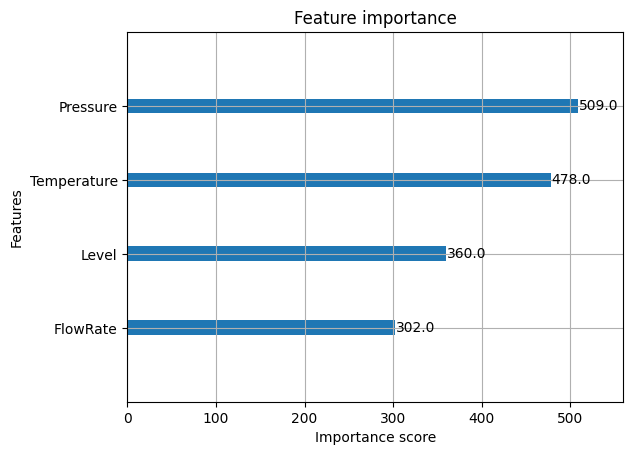

In [47]:
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()

In [48]:
from collections import Counter

print(Counter(y_encoded))

Counter({np.int64(1): 6214, np.int64(2): 3769, np.int64(0): 17})
